In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tickers = ['ISF.L', 'VWRL.L', 'IGLT.L', 'IBTM.L', 'INXG.L', 'SGLN.L', 'SLXX.L', 'IUKP.L']

data = yf.download(tickers, start='2020-01-01', end='2025-01-01')['Close']

data.head()

[*********************100%***********************]  8 of 8 completed


Ticker,IBTM.L,IGLT.L,INXG.L,ISF.L,IUKP.L,SGLN.L,SLXX.L,VWRL.L
Date,,,,,,,,
2020-01-02,129.042435,11.622165,15.791016,747.732117,665.819763,2271.25,121.932083,64.181488
2020-01-03,130.370468,11.714338,15.954246,750.326355,664.372803,2316.00,122.366211,64.239967
2020-01-06,129.635452,11.649397,15.856643,745.137817,655.641418,2323.00,122.245628,63.767574
2020-01-07,130.086502,11.655683,15.766619,745.038086,657.238037,2341.00,122.205444,64.176964
2020-01-08,130.353745,11.626354,15.730435,744.838684,648.656555,2343.00,122.048653,64.370445


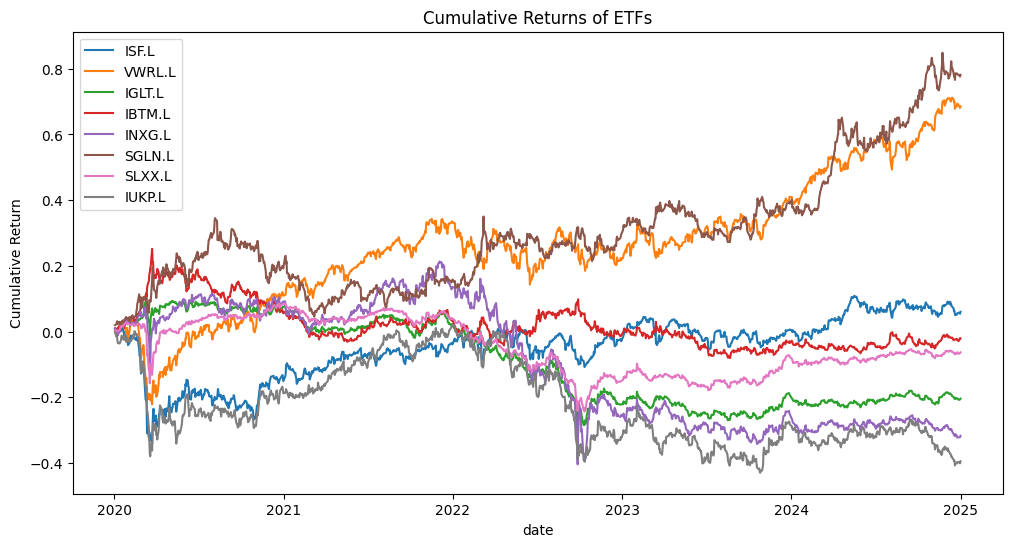

In [2]:
data = data.dropna()
returns = data.pct_change().dropna()
cumulative_returns = (1 + returns).cumprod() - 1
cumulative_returns.head()
plt.figure(figsize=(12,6))
for ticker in tickers:
    plt.plot(cumulative_returns.index, cumulative_returns[ticker], label=ticker)
plt.title('Cumulative Returns of ETFs')
plt.xlabel('date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.savefig('outputs/cumulative_returns.png', dpi=300, bbox_inches='tight')

In [3]:
mean_returns = returns.mean()
## print(mean_returns)
annual_mean_returns = mean_returns * 252
## print(annual_mean_returns)
cov_matrix = returns.cov()
## print(cov_matrix)
corr_matrix = returns.corr()
##print(corr_matrix)

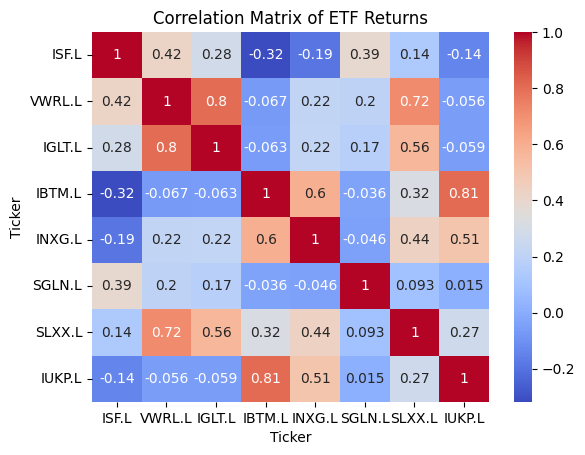

In [6]:
import seaborn as sns

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', xticklabels=tickers, yticklabels=tickers)
plt.title('Correlation Matrix of ETF Returns')
plt.savefig('outputs/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
weights = np.array([1/len(tickers)] * len(tickers))
rfr = 0.04
## UK short term gov bond yield

def portfolio_perf(weights, mean_returns, cov_matrix):
    portfolio_return = np.dot(weights, mean_returns)
    portfolio_variance = np.dot(weights.T, np.dot(cov_matrix * 252, weights))
    portfolio_volatility = np.sqrt(portfolio_variance)
    sharpe_ratio = (portfolio_return -rfr) / portfolio_volatility
    return portfolio_return, portfolio_volatility, sharpe_ratio, portfolio_variance

portfolio_return, portfolio_volatility, sharpe_ratio, portfolio_variance = portfolio_perf(weights, annual_mean_returns, cov_matrix)

print(f"Return: {portfolio_return:.4f}")
print(f"Volatility: {portfolio_volatility:.4f}")
print(f"Sharpe: {sharpe_ratio:.4f}")
print(f"Variance: {portfolio_variance:.4f}")

Return: 0.0122
Volatility: 0.0887
Sharpe: -0.3136
Variance: 0.0079


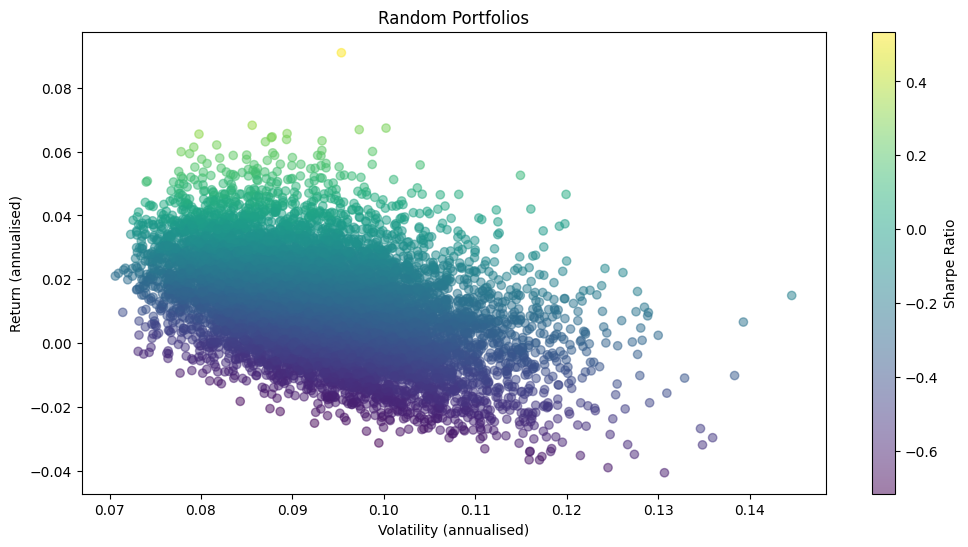

In [8]:
returns_list = []
vols_list = []
sharpes_list = []
vars_list = []
weights_list = []

for i in range(10000):
    weights = np.random.random(len(tickers))
    norm_weights = weights / np.sum(weights)
    ret, vol, sharpe, var = portfolio_perf(norm_weights, annual_mean_returns, cov_matrix)
    returns_list.append(ret)
    vols_list.append(vol)
    sharpes_list.append(sharpe)
    vars_list.append(var)
    weights_list.append(norm_weights)

returns_arr = np.array(returns_list)
vols_arr = np.array(vols_list)
sharpes_arr = np.array(sharpes_list)
vars_arr = np.array(vars_list)

plt.figure(figsize=(12,6))
plt.scatter(vols_arr, returns_arr, c=sharpes_arr, cmap='viridis', alpha=0.5)
plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Volatility (annualised)')
plt.ylabel('Return (annualised)')
plt.title('Random Portfolios')
plt.savefig('outputs/random_portfolios.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
best_rndportfolio = np.argmax(sharpes_arr)

print("Weights:")
for ticker, w in zip(tickers, weights_list[best_rndportfolio]):
    print(f"  {ticker}: {w:.4f}")

print(f"Best random Sharpe: {sharpes_arr[best_rndportfolio]:.4f}")
print(f"Return: {returns_arr[best_rndportfolio]:.4f}")
print(f"Volatility: {vols_arr[best_rndportfolio]:.4f}")
print(f"Variance: {vars_arr[best_rndportfolio]:.4f}")

Weights:
  ISF.L: 0.0650
  VWRL.L: 0.0169
  IGLT.L: 0.0572
  IBTM.L: 0.0380
  INXG.L: 0.0317
  SGLN.L: 0.3904
  SLXX.L: 0.0000
  IUKP.L: 0.4007
Best random Sharpe: 0.5345
Return: 0.0910
Volatility: 0.0954
Variance: 0.0091


In [10]:
def negative_sharpe(weights, mean_returns, cov_matrix, rfr):
    portfolio_return = np.dot(weights, mean_returns)
    portfolio_variance = np.dot(weights.T, np.dot(cov_matrix * 252, weights))
    portfolio_volatility = np.sqrt(portfolio_variance)
    sharpe_ratio = (portfolio_return -rfr) / portfolio_volatility
    return -sharpe_ratio

In [11]:
## i have simply understood up to this point, from here on, i needed to understand the process more than the code so i added explanations
## now we need to optimise - this must be in accordance with a few constraints:
## 1. weights sum to 1
## 2. weights are indiviudally between 0 and 1 (i learnt these are should be labelled bounds rather than constraints)

constraint_1 = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}
## 'eq' means that the constraint must equal to 0, the lambda function is a shortcut of the sum to one function
constraints = [constraint_1,]
bounds = tuple((0, 1) for i in range(len(tickers)))
## this creates a tuple of (0,1) for the number of tickers

from scipy.optimize import minimize

first_guess = np.array([1/len(tickers)] * len(tickers))

opt_results = minimize(negative_sharpe, first_guess, args=(annual_mean_returns, cov_matrix, rfr), method='SLSQP', bounds=bounds, constraints=constraints)
## SLSQP is least squares method (as commonly used)


opt_results

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: -0.7625305786178137
           x: [ 0.000e+00  0.000e+00  2.170e-16  6.282e-16  5.787e-16
                5.606e-01  2.850e-16  4.394e-01]
         nit: 4
         jac: [ 1.429e-01  4.592e-01  6.436e-01  3.480e-01  1.152e+00
               -3.725e-01  2.459e-01 -3.730e-01]
        nfev: 36
        njev: 4
 multipliers: [-3.727e-01]

In [12]:
optimal_weights = opt_results.x

print("Weights:")
for ticker, weight in zip(data.columns, optimal_weights):
    print(f"  {ticker}: {weight:.4f}")


opt_ret, opt_vol, opt_sharpe, opt_var = portfolio_perf(optimal_weights, annual_mean_returns, cov_matrix)
print(f"\n  Return: {opt_ret:.4f}")
print(f"  Volatility: {opt_vol:.4f}")
print(f"  Variance: {opt_var:.4f}")
print(f"  Sharpe Ratio: {opt_sharpe:.4f}")

## clearly the optimisation has given a much greater sharpe ratio (higher return for lower volatility)
## it also suggested a portfolio effectively solely invested in SGLN and VWRL, these are gold and global equities respectively

Weights:
  IBTM.L: 0.0000
  IGLT.L: 0.0000
  INXG.L: 0.0000
  ISF.L: 0.0000
  IUKP.L: 0.0000
  SGLN.L: 0.5606
  SLXX.L: 0.0000
  VWRL.L: 0.4394

  Return: 0.1218
  Volatility: 0.1073
  Variance: 0.0115
  Sharpe Ratio: 0.7625


In [13]:
## working towards the efficint frontier:
## find minimum variance portfolio

def portfolio_volatility(weights, mean_returns, cov_matrix):
    return portfolio_perf(weights, mean_returns, cov_matrix)[3]

min_var_result = minimize(portfolio_volatility, first_guess, args=(annual_mean_returns, cov_matrix), method='SLSQP', bounds=bounds, constraints=constraints)

min_var_weights = min_var_result.x

print("Weights:")
for ticker, weight in zip(data.columns, min_var_weights):
    print(f"  {ticker}: {weight:.4f}")

m_ret, m_vol, m_sharpe, m_var = portfolio_perf(min_var_weights, annual_mean_returns, cov_matrix)
print(f"\n  Return: {m_ret:.4f}")
print(f"  Volatility: {m_vol:.4f}")
print(f"  Variance: {m_var:.4f}")
print(f"  Sharpe Ratio: {m_sharpe:.4f}")

Weights:
  IBTM.L: 0.4046
  IGLT.L: 0.1073
  INXG.L: 0.0000
  ISF.L: 0.1518
  IUKP.L: 0.0000
  SGLN.L: 0.0815
  SLXX.L: 0.1847
  VWRL.L: 0.0699

  Return: 0.0174
  Volatility: 0.0682
  Variance: 0.0047
  Sharpe Ratio: -0.3314


In [14]:
print(f"{'Metric':<15}{'Max Sharpe':<15}{'Min Variance':<15}")
print("-" * 45)
print(f"{'Return':<15}{opt_ret:<15.4f}{m_ret:<15.4f}")
print(f"{'Volatility':<15}{opt_vol:<15.4f}{m_vol:<15.4f}")
print(f"{'Variance':<15}{opt_var:<15.4f}{m_var:<15.4f}")
print(f"{'Sharpe':<15}{opt_sharpe:<15.4f}{m_sharpe:<15.4f}")

Metric         Max Sharpe     Min Variance   
---------------------------------------------
Return         0.1218         0.0174         
Volatility     0.1073         0.0682         
Variance       0.0115         0.0047         
Sharpe         0.7625         -0.3314        


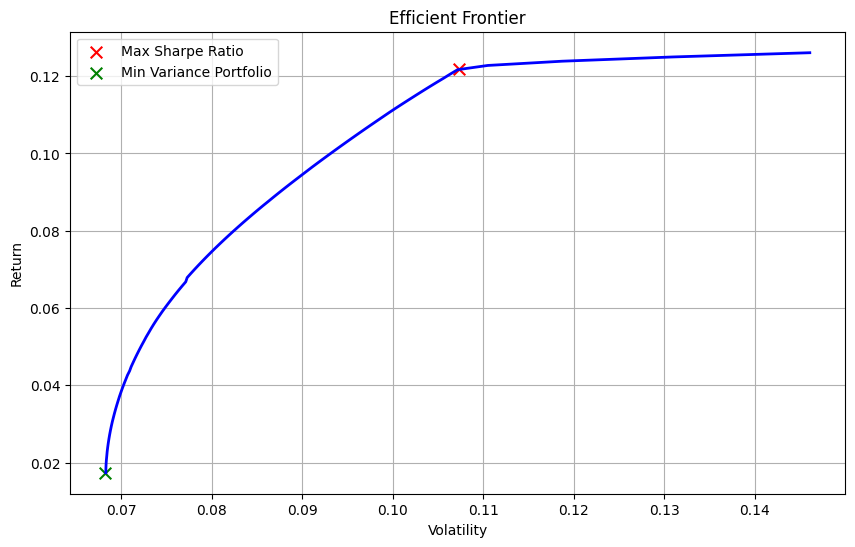

In [15]:
## for efficient frontier, need to find the relevant optimal portfolio for target returns between the min and max return

from unittest import result


target_returns = np.linspace(m_ret, annual_mean_returns.max(), 100)
## 100 target returns equally spaced

## now use same optimisation as before with additional constraint (portfolio return = target return)
frontier_vols = []

for target_return in target_returns:
    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w, t=target_return: np.dot(w, annual_mean_returns) - t} ]
    frontier = minimize(portfolio_volatility, first_guess, args=(annual_mean_returns, cov_matrix), method='SLSQP', bounds=bounds, constraints=constraints)
    frontier_vols.append(np.sqrt(frontier.fun))

plt.figure(figsize=(10, 6))
plt.plot(frontier_vols, target_returns, 'b-', linewidth=2)
plt.scatter(opt_vol, opt_ret, c='red', marker='x', s=70, label='Max Sharpe Ratio')
plt.scatter(m_vol, m_ret, c='green', marker='x', s=70, label='Min Variance Portfolio')
plt.xlabel('Volatility')
plt.ylabel('Return')
plt.title('Efficient Frontier')
plt.legend()
plt.grid(True)
plt.savefig('outputs/efficient_frontier.png', dpi=300, bbox_inches='tight')
plt.show()


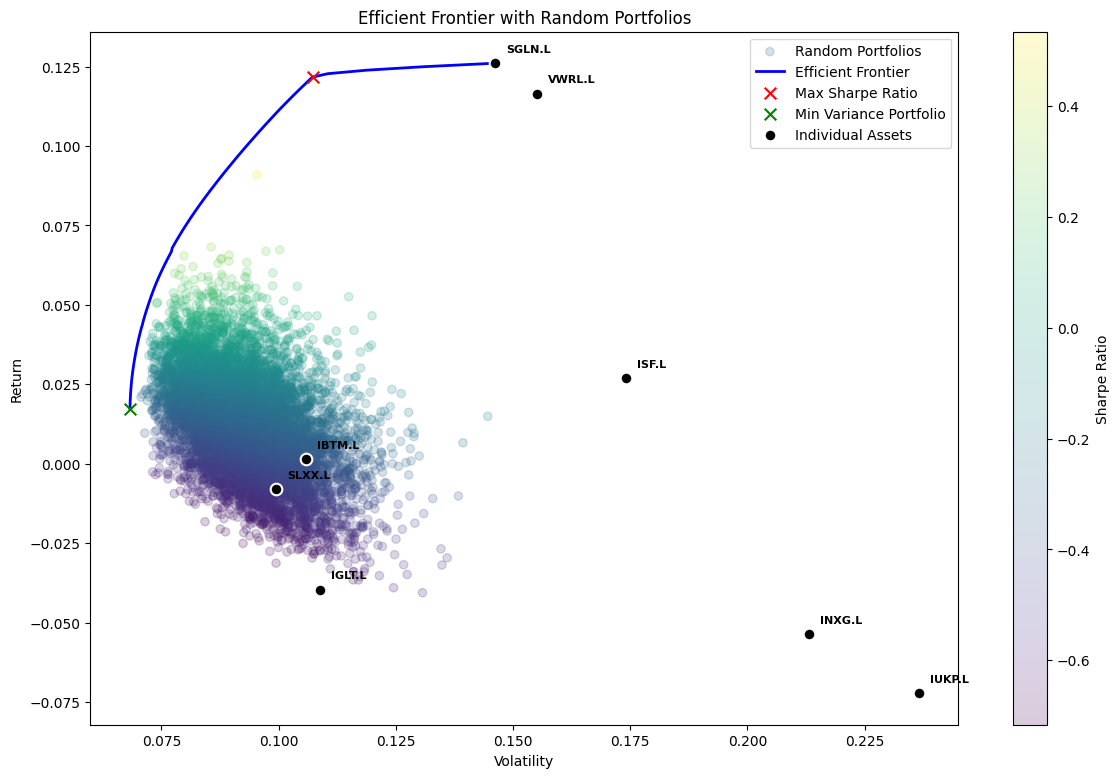

In [16]:
## Final Plot
asset_vols = np.sqrt(np.diag(cov_matrix * 252))
asset_returns = annual_mean_returns


plt.figure(figsize=(14, 9))
plt.scatter(vols_arr, returns_arr, c=sharpes_arr, cmap='viridis', alpha=0.2, label='Random Portfolios')
plt.colorbar(label='Sharpe Ratio')
plt.plot(frontier_vols, target_returns, 'b-', linewidth=2, label='Efficient Frontier')
plt.scatter(opt_vol, opt_ret, c='red', marker='x', s=70, label='Max Sharpe Ratio', zorder=5)
plt.scatter(m_vol, m_ret, c='green', marker='x', s=70, label='Min Variance Portfolio', zorder=5)
plt.xlabel('Volatility')
plt.ylabel('Return')
plt.title('Efficient Frontier with Random Portfolios')
plt.scatter(asset_vols, asset_returns, marker='o', s=70, 
            color='black', edgecolor='white', linewidth=1.5,
            label='Individual Assets', zorder=5)
for ticker, vol, ret in zip(data.columns, asset_vols, asset_returns):
    plt.annotate(ticker, (vol, ret), xytext=(8, 8), textcoords='offset points', fontsize=8, fontweight='bold')

plt.legend()
plt.savefig('outputs/efficient_frontier_with_random.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
import pandas as pd
eq_weights = np.array([1/len(tickers)] * len(tickers))
eq_ret, eq_vol, eq_sharpe, _ = portfolio_perf(eq_weights, annual_mean_returns, cov_matrix)

summary = pd.DataFrame({
    'Equal Weight': [eq_ret, eq_vol, eq_sharpe],
    'Max Sharpe': [opt_ret, opt_vol, opt_sharpe],
    'Min Variance': [m_ret, m_vol, m_sharpe]
}, index=['Annualised Return', 'Annualised Volatility', 'Sharpe Ratio'])

print(summary.round(4))

                       Equal Weight  Max Sharpe  Min Variance
Annualised Return            0.0122      0.1218        0.0174
Annualised Volatility        0.0887      0.1073        0.0682
Sharpe Ratio                -0.3136      0.7625       -0.3314


In [21]:
weights_summary = pd.DataFrame({
    'Equal Weight': [1/len(tickers)] * len(tickers),
    'Max Sharpe': optimal_weights,
    'Min Variance': min_var_weights
}, index=data.columns)

## print(weights_summary.round(4))

In [24]:
summary.to_csv('outputs/portfolio_metrics.csv')
weights_summary.to_csv('outputs/portfolio_weights.csv')

print(summary.round(4).to_markdown())
print(weights_summary.round(4).to_markdown())

|                       |   Equal Weight |   Max Sharpe |   Min Variance |
|:----------------------|---------------:|-------------:|---------------:|
| Annualised Return     |         0.0122 |       0.1218 |         0.0174 |
| Annualised Volatility |         0.0887 |       0.1073 |         0.0682 |
| Sharpe Ratio          |        -0.3136 |       0.7625 |        -0.3314 |
| Ticker   |   Equal Weight |   Max Sharpe |   Min Variance |
|:---------|---------------:|-------------:|---------------:|
| IBTM.L   |          0.125 |       0      |         0.4046 |
| IGLT.L   |          0.125 |       0      |         0.1073 |
| INXG.L   |          0.125 |       0      |         0      |
| ISF.L    |          0.125 |       0      |         0.1518 |
| IUKP.L   |          0.125 |       0      |         0      |
| SGLN.L   |          0.125 |       0.5606 |         0.0815 |
| SLXX.L   |          0.125 |       0      |         0.1847 |
| VWRL.L   |          0.125 |       0.4394 |         0.0699 |


In [25]:
print("=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)
print(f"Equal-weight portfolio Sharpe: {eq_sharpe:.4f}")
print(f"Maximum Sharpe portfolio:      {opt_sharpe:.4f}")
print(f"Minimum variance volatility:   {m_vol:.4f} ({m_vol*100:.2f}%)")
print(f"\nOptimisation improved Sharpe by {opt_sharpe - eq_sharpe:.4f}")
print(f"({(opt_sharpe - eq_sharpe) / abs(eq_sharpe) * 100:.0f}% relative improvement)")

RESULTS SUMMARY
Equal-weight portfolio Sharpe: -0.3136
Maximum Sharpe portfolio:      0.7625
Minimum variance volatility:   0.0682 (6.82%)

Optimisation improved Sharpe by 1.0761
(343% relative improvement)
